In [1]:
import matplotlib.pyplot as plt
import numpy as np

import jax
from jax import vmap
import jax.numpy as jnp
import jax.random as random

import numpyro
import optax
from numpyro import handlers
from numpyro.infer import SVI, Trace_ELBO, Predictive 
import numpyro.distributions as dist
from numpyro.infer.autoguide import AutoNormal
from numpyro.contrib.einstein import RBFKernel, SteinVI, MixtureGuidePredictive
from numpyro.optim import Adagrad

from sklearn.model_selection import train_test_split

from collections import namedtuple
from functools import partial

/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DataState = namedtuple("data", ["xtr", "xte", "ytr", "yte"])
def load_data(x, y, test_size) -> DataState:
    xtr, xte, ytr, yte = train_test_split(
        x, y, test_size=test_size, random_state=1
    )

    return DataState(
        *map(partial(jnp.array, dtype=float), (xtr, xte, ytr, yte))
    )

def normalize(val, mean=None, std=None):
    """Normalize data to zero mean, unit variance"""
    if mean is None and std is None:
        # Only use training data to estimate mean and std.
        std = jnp.std(val, 0, keepdims=True)
        std = jnp.where(std == 0, 1.0, std)
        mean = jnp.mean(val, 0, keepdims=True)
    return (val - mean) / std, mean, std

In [20]:
from gpkanmodel.test_functions import himmelblau 
f = lambda x, y: himmelblau(x, y) 

samples = 30
x1, x2 = jnp.meshgrid(jnp.linspace(-5, 5, samples), jnp.linspace(-5 , 5, samples))
X = jnp.stack([x1.flatten(), x2.flatten()]).T
y = f(X[:, 0], X[:, 1]).reshape(-1, 1)

data = load_data(X, y, test_size=0.2)
x, xtr_mean, xtr_std = normalize(data.xtr)
y, ytr_mean, ytr_std = normalize(data.ytr)

In [4]:
# def model(X, Y, D_H, D_Y=1):
#     N, D_X = X.shape

#     w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
#     b1 = numpyro.sample("b1", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
#     assert w1.shape == (D_X, D_H)
#     z1 = jnp.tanh(jnp.matmul(X, w1) + b1) # <= first layer of activations
#     assert z1.shape == (N, D_H)

#     w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
#     b2 = numpyro.sample("b2", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
#     assert w2.shape == (D_H, D_H)
#     z2 = jax.nn.relu(jnp.matmul(z1, w2) + b2)   # <= second layer of activations
#     assert z2.shape == (N, D_H)

#     w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
#     b3 = numpyro.sample("b3", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
#     assert w3.shape == (D_H, D_H)
#     z3 = jax.nn.relu(jnp.matmul(z2, w3) + b3)  # <= second layer of activations
#     assert z3.shape == (N, D_H)

#     w4 = numpyro.sample("w4", dist.Normal(jnp.zeros((D_H, D_Y)), jnp.ones((D_H, D_Y))))
#     b4 = numpyro.sample("b4", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
#     assert w4.shape == (D_H, D_Y)
#     z4 = jnp.matmul(z3, w4) + b4
#     assert z4.shape == (N, D_Y)

#     if Y is not None:
#         assert z4.shape == Y.shape

#     prec_obs = numpyro.sample("prec_obs", dist.Gamma(3.0, 1.0))
#     sigma_obs = 1.0 / jnp.sqrt(prec_obs)

#     with numpyro.plate("data", N):
#         numpyro.sample("Y", dist.Normal(z4, sigma_obs).to_event(1), obs=Y)

In [5]:
import jax.numpy as jnp
from jax import nn
import numpyro
import numpyro.distributions as dist
from numpyro import plate, sample

def model(x, y=None, hidden_dim=50, sub_size=samples**2):
    n, m = x.shape
    
    # 1. Hyper-priors for weight precision
    prec_nn = sample("prec_nn", dist.Gamma(1.0, 0.1))
    sigma_nn = 1.0 / jnp.sqrt(prec_nn)

    # 2. Layer 1: Input -> Hidden 1
    w1 = sample("w1", dist.Normal(jnp.zeros((m, hidden_dim)), sigma_nn))
    b1 = sample("b1", dist.Normal(jnp.zeros(hidden_dim), sigma_nn))
    
    # 3. Layer 2: Hidden 1 -> Hidden 2
    w2 = sample("w2", dist.Normal(jnp.zeros((hidden_dim, hidden_dim)), sigma_nn))
    b2 = sample("b2", dist.Normal(jnp.zeros(hidden_dim), sigma_nn))
    
    # 4. Layer 3: Hidden 2 -> Output
    w3 = sample("w3", dist.Normal(jnp.zeros((hidden_dim, 1)), sigma_nn))
    b3 = sample("b3", dist.Normal(jnp.zeros(1), sigma_nn))

    # 5. Observation Noise
    prec_obs = sample("prec_obs", dist.Gamma(3.0, 1.0))
    sigma_obs = 1.0 / jnp.sqrt(prec_obs)

    # 6. Data Plate (conditionally independent across observations)
    # Note: We do NOT specify dim=-1 here.
    with plate("data", n, subsample_size=sub_size):
        # Subsample x and y if necessary
        batch_x = numpyro.subsample(x, event_dim=1)
        batch_y = numpyro.subsample(y, event_dim=0) if y is not None else None

        # Forward Pass
        # jnp.matmul handles (particles, n, m) @ (m, hidden) -> (particles, n, hidden)
        h1 = nn.tanh(jnp.matmul(batch_x, w1) + b1)
        h2 = nn.tanh(jnp.matmul(h1, w2) + b2)
        # Final output shape: (particles, n, 1) -> squeeze to (particles, n)
        mu = (jnp.matmul(h2, w3) + b3).squeeze(-1)

        # Likelihood
        sample("y", dist.Normal(mu, sigma_obs), obs=batch_y)

In [6]:
guide = AutoNormal(model)
optimizer = optax.adam(0.01)
svi = SVI(model, guide, optimizer, Trace_ELBO())

In [7]:
rng_key = jax.random.PRNGKey(0)
svi_result = svi.init(rng_key, x, y)

losses = []
for i in range(500):
    svi_result, loss = svi.update(svi_result, x, y)
    losses.append(loss)
    if (i + 1) % 100 == 0:
        print(f"  Step {i+1}: loss = {loss:.4f}")

/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/2864498194.py:2: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  svi_result = svi.init(rng_key, x, y)
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. D

  Step 100: loss = 3675359.5000


/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = self.f(*args, **dict(self.params, **kwargs))
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing 

  Step 200: loss = 2767427.5000


/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = self.f(*args, **dict(self.params, **kwargs))
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing 

...

/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = self.f(*args, **dict(self.params, **kwargs))
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing 

  Step 400: loss = 1779007.7500


/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = self.f(*args, **dict(self.params, **kwargs))
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing 

  Step 500: loss = 1680143.2500


/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = self.f(*args, **dict(self.params, **kwargs))
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_28780/3376452323.py:32: UserWarning: subsample_size does not match len(subsample), 900 vs 720. Did you accidentally use different subsample_size in the model and guide?
  with plate("data", n, subsample_size=sub_size):
/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/jax/_src/linear_util.py:192: UserWarning: Missing 

In [8]:
print(min(losses), max(losses))

1433171.4 233367580.0


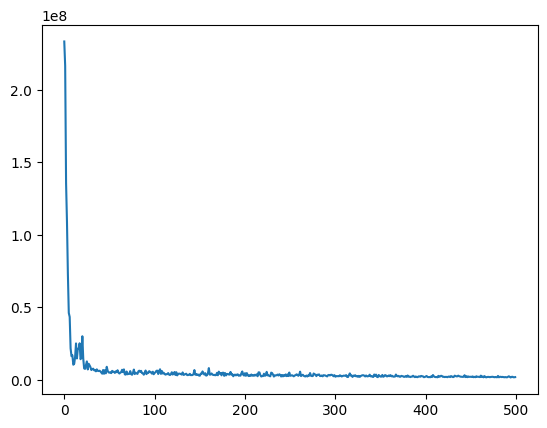

In [9]:
plt.plot(losses)
plt.show()

In [10]:
svi_result.optim_state

(Array(500, dtype=int32, weak_type=True),
 ({'b1_auto_loc': Array([ 0.82000434,  0.06728783,  1.931945  ,  1.6552279 ,  2.0091298 ,
           0.8754593 , -1.140278  ,  1.8062532 ,  0.29179096, -1.4119596 ,
          -1.0921382 , -1.1070514 , -0.01322494, -0.35344353, -0.47951075,
           1.5291581 ,  0.98631406, -1.8676804 ,  0.5190719 , -0.74244344,
          -1.5452347 , -1.620954  ,  1.8039516 ,  0.17914613,  1.5150954 ,
           0.15829527,  0.72761536,  2.0987458 , -1.4928154 , -0.3149481 ,
          -0.21094531,  1.2299657 , -0.3011721 ,  1.1440765 ,  1.8204433 ,
           1.6342952 ,  0.4528794 ,  0.6487813 ,  0.19950293, -1.1960118 ,
          -1.5510293 ,  1.6994569 ,  1.8700309 ,  0.07889471,  0.5858989 ,
           2.0770204 , -0.74945176, -2.0711842 ,  0.51258475,  0.01894852],      dtype=float32),
   'b1_auto_scale': Array([-2.513026 , -2.4196017, -2.3044803, -2.4614553, -2.3432584,
          -2.918531 , -2.3700366, -2.358596 , -2.7048068, -2.4662986,
          -2.4

In [11]:
predictive = Predictive(model, guide=guide, params=svi_result.optim_state, num_samples=500)
rng_key = jax.random.PRNGKey(1)

In [18]:
X_norm, _, _ = normalize(X, xtr_mean, xtr_std)
y_pred = predictive(rng_key, X_norm)

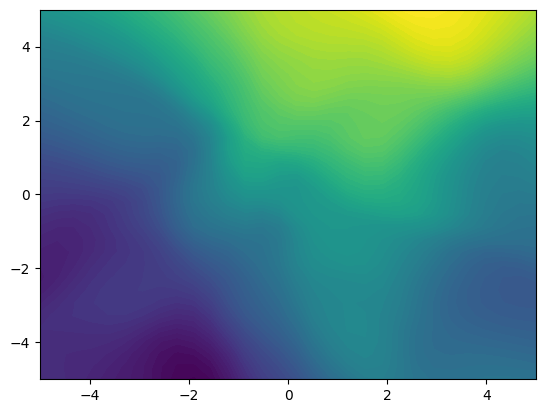

In [19]:
res = y_pred["y"].mean(0)
plt.contourf(x1, x2, res.reshape(30, 30), levels=100)
plt.show()

In [23]:
y.shape

(720, 1)

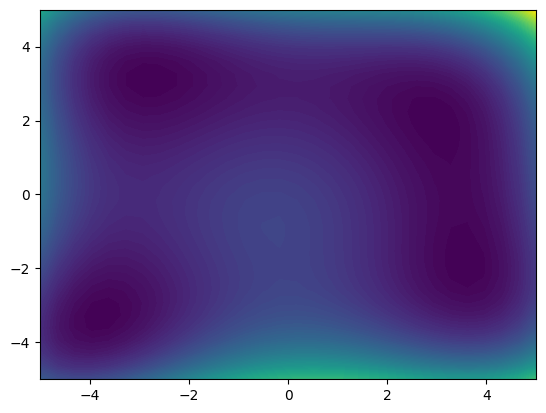

In [24]:
plt.contourf(x1, x2, f(X[:, 0], X[:, 1]).reshape(30, 30), levels=100)
plt.show()